In [ ]:
from pathlib import Path

def find_project_root(start=None, markers=("run_all.py", "requirements.txt")):
    p = Path(start or Path.cwd()).resolve()
    for candidate in (p, *p.parents):
        if any((candidate / m).exists() for m in markers):
            return candidate
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from pathlib import Path

# Read the CSV file (created by 1_analyze_truckstops_services_match_rates.ipynb)
FIGURES_DIR = Path(OUTPUT_DIR / "2_analysis/figures/analyze_truckstops_services_website_matching")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(OUTPUT_DIR / "2_analysis/tables/1_truckstops_services_website_matching_match_rates.csv")

In [3]:
df

,clean_line1,clean_line2,line3,city,zip_code,label,phone,year,major_city,state,...,has_phone_match,ZIP_scraped_matches_row_ids_parsed,State_scraped_matches_row_ids_parsed,City_scraped_matches_row_ids_parsed,Exit_scraped_matches_row_ids_parsed,Road_scraped_matches_row_ids_parsed,Label_scraped_matches_row_ids_parsed,Chain_scraped_matches_row_ids_parsed,Success_Match_Rate,Phone_Success_Match_Rate
0,"Blandford , 01008 Blandford Plaza EB Exxon # 5020",413-848-2056 I-90 ( MATP ) MM 29 EB,<U+25A1> <U+2610>,Blandford,1008,Blandford Plaza EB Exxon # 5020,413-848-2056,2006,Blandford,MA,...,True,[],[ 2746 2747 2748 2749 2750 2751 2752 27...,[10518 10517 2750 2751],[],[12291 2054 12304 2065 12306 14355 2068 123...,[14337 6146 4 6148 6150 14347 14350 143...,[14337 6146 4 6148 6150 14347 14350 143...,6/6 successful match,True
1,"Blandford , 01008 Blandford Plaza EB Exxon # 5020",413-848-2056 I-90 ( MATP ) MM 29 EB,24 HRS S,Blandford,1008,Blandford Plaza EB Exxon # 5020,413-848-2056,2007,Blandford,MA,...,True,[],[ 2746 2747 2748 2749 2750 2751 2752 27...,[10518 10517 2750 2751],[],[12291 2054 12304 2065 12306 14355 2068 123...,[14337 6146 4 6148 6150 14347 14350 143...,[14337 6146 4 6148 6150 14347 14350 143...,6/6 successful match,True
2,"Blandford , 01008 Blandford Plaza EB Exxon # 5020",413-848-2056 I-90 ( MATP ) MM 29 EB,HAS 24 SO <U+2610> <U+2610>,Blandford,1008,Blandford Plaza EB Exxon # 5020,413-848-2056,2008,Blandford,MA,...,True,[],[ 2746 2747 2748 2749 2750 2751 2752 27...,[10518 10517 2750 2751],[],[12291 2054 12304 2065 12306 14355 2068 123...,[14337 6146 4 6148 6150 14347 14350 143...,[14337 6146 4 6148 6150 14347 14350 143...,6/6 successful match,True
3,D Blandford ( 01008 ) Blandford Plaza EB # 902...,413-848-2056 I-90 ( MATP ) MM 29 EB,24 S <U+2610>,Blandford,1008,Blandford Plaza EB # 9020 ( Gulf ),413-848-2056,2014,Blandford,MA,...,True,[],[ 2746 2747 2748 2749 2750 2751 2752 27...,[10518 10517 2750 2751],[],[12291 2054 12304 2065 12306 14355 2068 123...,[14874 4658 59 11836 62 2633 12370 72...,[14874 4658 59 62 2633 12370 7272 42...,7/6 successful match,True
4,D Blandford ( 01008 ) Blandford Plaza EB # 902...,2 413-848-2056 I-90 ( MATP ) MM 29 EB,24 S,Blandford,1008,Blandford Plaza EB # 9020 ( Gulf ),413-848-2056,2015,Blandford,MA,...,True,[],[ 2746 2747 2748 2749 2750 2751 2752 27...,[10518 10517 2750 2751],[],[12291 2054 12304 2065 12306 14355 2068 123...,[14874 4658 59 11836 62 2633 12370 72...,[14874 4658 59 62 2633 12370 7272 42...,7/6 successful match,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1897,"Snow Shoe , 16874 Reese Truck Stop ( Exxon )",814-387-6203 I-80 Exit 147 ( PA 144 ),24 ( SY HRS,Snow Shoe,16874,Reese Truck Stop ( Exxon ),814-387-6203,2007,Snow Shoe,PA,...,False,[ 5461 5511 13144 13179],[ 5308 5309 5310 5311 5312 5313 5314 53...,[13144 13179 5461 5511],[ 5511 6924 14093 15118 1822 14112 9122 96...,[ 4100 4101 2054 4106 4110 4111 4112 20...,[14337 6146 4 6148 6150 14347 14350 143...,[14337 6146 4 6148 6150 14347 14350 143...,6/6 successful match,False
1898,"D Snow Shoe , 16874 Reese Truck Stop ( Exxon )",5 814-387-6203 I-80 Exit 147 ( PA 144 ),24 HRS XL 24 <U+2610><U+2610>,Snow Shoe,16874,Reese Truck Stop ( Exxon ),814-387-6203,2008,Snow Shoe,PA,...,False,[ 5461 5511 13144 13179],[ 5308 5309 5310 5311 5312 5313 5314 53...,[13144 13179 5461 5511],[ 5511 6924 14093 15118 1822 14112 9122 96...,[ 4100 4101 2054 4106 4110 4111 4112 20...,[14337 6146 4 6148 6150 14347 14350 143...,[14337 6146 4 6148 6150 14347 14350 143...,6/6 successful match,False
1899,D Snow Shoe ( 16874 ) Reese Truck Stop ( Exxon ),814-387-6203 I-80 Exit 147 ( PA 144 ),XL <U+25A1> <U+25A1>,Snow Shoe,16874,Reese Truck Stop ( Exxon ),814-387-6203,2014,Snow Shoe,PA,...,False,[ 5461 5511 13144 13179],[ 5308 5309 5310 5311 5312 5313 5314 53...,[13144 13179 5461 5511],[ 5511 6924 14093 15118 1822 14112 9122 96...,[ 4100 4101 2054 4106 4110 4111 4112 20...,[14337 6146 4 6148 6150 14347 14350 143...

# Analysis of Success Rates

Let's count how many rows have:
1. `Phone_Success_Match_Rate=True`
2. `Success_Match_Rate` equal to "6/6 successful match"
3. `Success_Match_Rate` equal to "7/6 successful match"

In [4]:
# Count rows where Phone_Success_Match_Rate is True
phone_success_count = df['Phone_Success_Match_Rate'].sum()
print(f"Number of rows with Phone_Success_Match_Rate=True: {phone_success_count}")

Number of rows with Phone_Success_Match_Rate=True: 1608


In [5]:
# Count rows where Success_Match_Rate is "6/6 successful match" or "7/6 successful match"
six_six_count = (df['Success_Match_Rate'] == '6/6 successful match').sum()
seven_six_count = (df['Success_Match_Rate'] == '7/6 successful match').sum()

print(f"Number of rows with Success_Match_Rate='6/6 successful match': {six_six_count}")
print(f"Number of rows with Success_Match_Rate='7/6 successful match': {seven_six_count}")

# Total count of rows with either condition
total_count = six_six_count + seven_six_count
print(f"Total rows with Success_Match_Rate='6/6 successful match' or '7/6 successful match': {total_count}")

Number of rows with Success_Match_Rate='6/6 successful match': 308
Number of rows with Success_Match_Rate='7/6 successful match': 1129
Total rows with Success_Match_Rate='6/6 successful match' or '7/6 successful match': 1437


In [6]:
# Count rows that meet any of the conditions (Phone_Success_Match_Rate=True OR Success_Match_Rate='6/6 successful match' OR Success_Match_Rate='7/6 successful match')
combined_condition = (
    df['Phone_Success_Match_Rate'] == True) | (
    df['Success_Match_Rate'] == '6/6 successful match') | (
    df['Success_Match_Rate'] == '7/6 successful match'
)

combined_count = combined_condition.sum()
print(f"Number of rows meeting any of the specified conditions: {combined_count}")
print(f"Percentage of total rows: {combined_count/len(df)*100:.2f}%")

Number of rows meeting any of the specified conditions: 1751
Percentage of total rows: 92.06%


# Analysis of Low Success Rates

Now let's identify the rows that do NOT have high success rates. These are rows that fail to meet any of these conditions:
- `Phone_Success_Match_Rate=True`
- `Success_Match_Rate='6/6 successful match'`
- `Success_Match_Rate='7/6 successful match'`

In [7]:
# Count rows that do NOT meet any of the high success rate conditions
low_success_condition = ~(
    (df['Phone_Success_Match_Rate'] == True) | 
    (df['Success_Match_Rate'] == '6/6 successful match') | 
    (df['Success_Match_Rate'] == '7/6 successful match')
)

low_success_count = low_success_condition.sum()
print(f"Number of rows NOT meeting any of the high success conditions: {low_success_count}")
print(f"Percentage of total rows: {low_success_count/len(df)*100:.2f}%")

Number of rows NOT meeting any of the high success conditions: 151
Percentage of total rows: 7.94%


In [8]:
# Let's look at the distribution of Success_Match_Rate for these low success rows
low_success_df = df[low_success_condition]

print("Distribution of Success_Match_Rate values in low success rows:")
success_rate_distribution = low_success_df['Success_Match_Rate'].value_counts().sort_index()
for rate, count in success_rate_distribution.items():
    print(f"- {rate}: {count} rows ({count/len(low_success_df)*100:.2f}% of low success rows)")

print("\nPhone_Success_Match_Rate values in low success rows:")
phone_success_distribution = low_success_df['Phone_Success_Match_Rate'].value_counts()
for value, count in phone_success_distribution.items():
    print(f"- {value}: {count} rows ({count/len(low_success_df)*100:.2f}% of low success rows)")

Distribution of Success_Match_Rate values in low success rows:
- 2/6 successful match: 18 rows (11.92% of low success rows)
- 4/6 successful match: 53 rows (35.10% of low success rows)
- 5/6 successful match: 80 rows (52.98% of low success rows)

Phone_Success_Match_Rate values in low success rows:
- False: 151 rows (100.00% of low success rows)


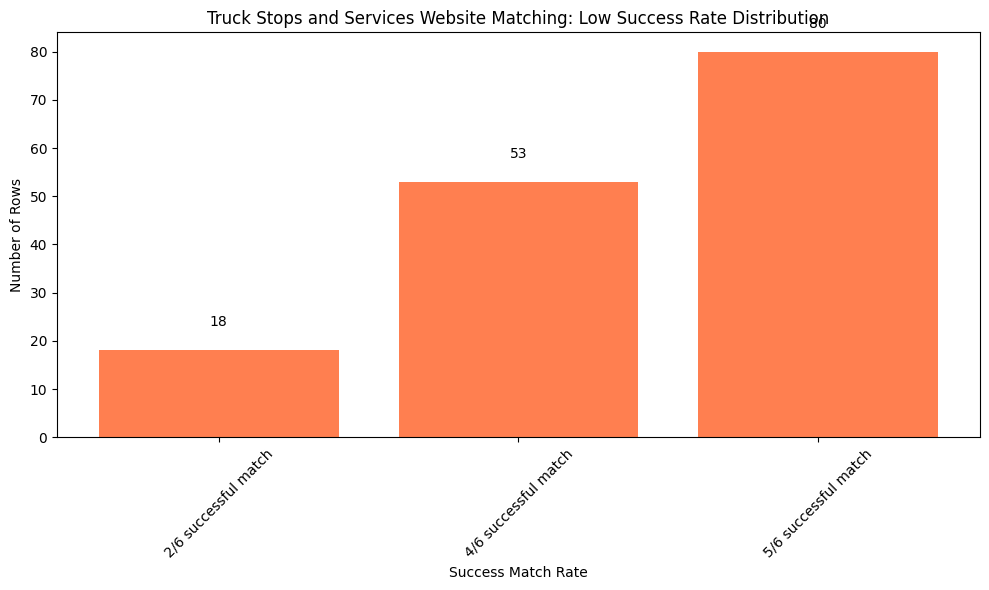

In [9]:
# Visualize the distribution of Success_Match_Rate in low success rows
plt.figure(figsize=(10, 6))
success_rates = success_rate_distribution.index
counts = success_rate_distribution.values

plt.bar(success_rates, counts, color='coral')
plt.xlabel('Success Match Rate')
plt.ylabel('Number of Rows')
plt.title('Truck Stops and Services Website Matching: Low Success Rate Distribution')
plt.xticks(rotation=45)

# Add data labels on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_truckstops_services_website_matching_low_success_rate_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Overall Distribution of Success Match Rates

Let's visualize the distribution of all Success Match Rates across the entire dataset to provide context:

Overall distribution of Success Match Rates in the entire dataset:
- 2/6 successful match: 24 rows (1.26% of all rows)
- 4/6 successful match: 95 rows (4.99% of all rows)
- 5/6 successful match: 346 rows (18.19% of all rows)
- 6/6 successful match: 308 rows (16.19% of all rows)
- 7/6 successful match: 1129 rows (59.36% of all rows)


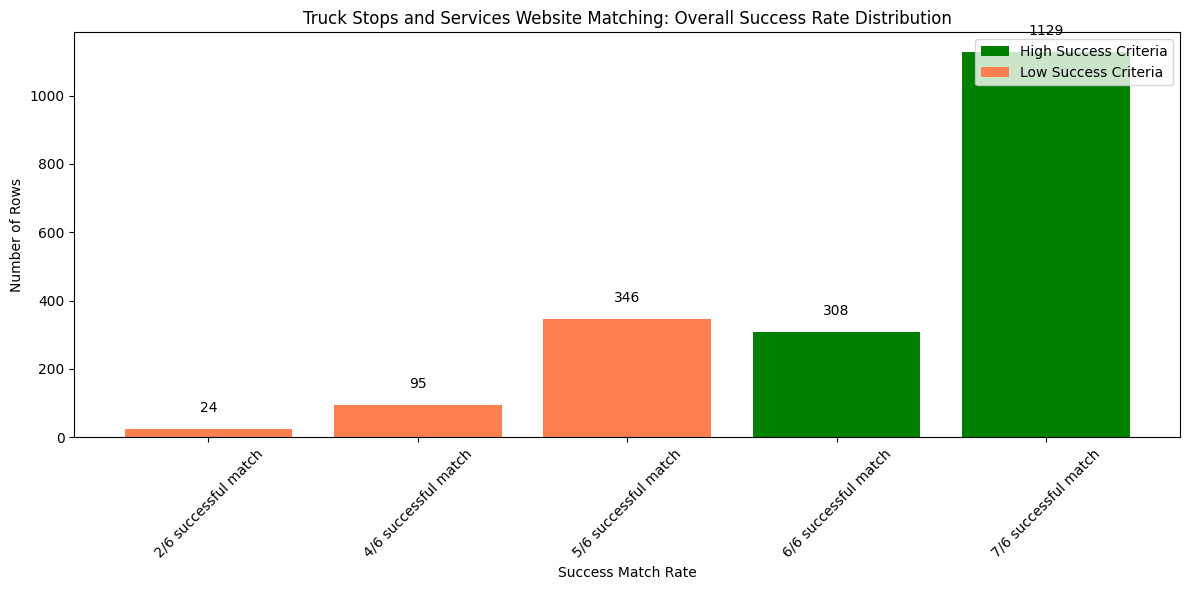

In [10]:
# Get the overall distribution of Success Match Rates
all_success_distribution = df['Success_Match_Rate'].value_counts().sort_index()
print("Overall distribution of Success Match Rates in the entire dataset:")
for rate, count in all_success_distribution.items():
    print(f"- {rate}: {count} rows ({count/len(df)*100:.2f}% of all rows)")

# Visualize the distribution
plt.figure(figsize=(12, 6))
success_rates = all_success_distribution.index
counts = all_success_distribution.values

# Create color mapping - high success rates in green, others in coral
colors = ['coral', 'coral', 'coral', 'green', 'green']
if len(success_rates) != len(colors):
    # Fallback if the number of unique rates doesn't match our expected colors
    colors = ['green' if rate in ['6/6 successful match', '7/6 successful match'] else 'coral' for rate in success_rates]

plt.bar(success_rates, counts, color=colors)
plt.xlabel('Success Match Rate')
plt.ylabel('Number of Rows')
plt.title('Truck Stops and Services Website Matching: Overall Success Rate Distribution')
plt.xticks(rotation=45)

# Add data labels on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center')

# Add a legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='High Success Criteria'),
    Patch(facecolor='coral', label='Low Success Criteria')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_truckstops_services_website_matching_overall_success_rate_distribution.png', dpi=300, bbox_inches='tight')
plt.show()